# Unit 5 · Combining models

Course: **21CSC305P — Machine Learning**

## Aim
Compare a small decision tree with random forest and AdaBoost classifiers.

## Assignment tasks
1. Implement CART learning algorithms to perform categorization.
2. Implement Ensemble learning models to perform classification.

## About this transport dataset
This is **real hourly road-sensor data** from westbound Interstate 94 between Minneapolis and Saint Paul, USA. A road sensor counts vehicles passing during each hour. We use **1,008 consecutive hours (42 days), from 13 April 2017 at 10:00 to 25 May 2017 at 09:00**, in the source's local timestamps.

**traffic_volume**: vehicles counted in that hour. **temperature_c**: air temperature in degrees Celsius. **date_time** identifies the hour and is not a numerical model feature.

The original dataset has 48,204 rows and includes weather and holidays from 2012–2018. Repeated weather descriptions can share a timestamp; their traffic counts were verified identical before keeping the first entry. The teaching CSV uses the first six weeks of the longest continuous hourly sequence. Temperature was converted from Kelvin by subtracting 273.15. No missing hours were filled and no measurements were invented.

Source: [UCI Metro Interstate Traffic Volume](https://archive.ics.uci.edu/dataset/492/metro+interstate+traffic+volume). Citation: Hogue, J. (2019), DOI: 10.24432/C5X60B. License: CC BY 4.0. The complete original compressed CSV is included.

**What to tell faculty:** “I am studying traffic patterns using real vehicle counts from a highway sensor.” High vehicle count means a busy hour; without speed or capacity data it does not prove congestion. This small window is a classroom demonstration, not a validation across roads or seasons.

Run cells from top to bottom. Keep the `data` folder beside `notebooks`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Run from the project folder or from its notebooks folder.
try:
    df = pd.read_csv('data/traffic.csv')
except FileNotFoundError:
    df = pd.read_csv('../data/traffic.csv')

df['date_time'] = pd.to_datetime(df['date_time'])
print('Number of traffic hours:', len(df))

Number of traffic hours: 1008


## Prepare the same prediction task
Use the same chronological split as Unit 2. The input is the current hourly count; the target is whether the following hour reaches 4000 vehicles. Tree models can use vehicle counts directly without standardization.

In [2]:
# Each row is exactly one hour after the preceding row.
data = df.copy()
data['next_volume'] = data['traffic_volume'].shift(-1)
data = data.dropna()  # The last hour has no measured following hour.

# Earlier hours teach the model; later hours test it.
split = int(len(data) * 0.8)
train = data.iloc[:split]
test = data.iloc[split:]
print('Training rows:', len(train), '| Testing rows:', len(test))
display(data.head())

Training rows: 805 | Testing rows: 202


,date_time,traffic_volume,temperature_c,next_volume
0,2017-04-13 10:00:00,4576,8.26,5033.0
1,2017-04-13 11:00:00,5033,8.75,5138.0
2,2017-04-13 12:00:00,5138,9.00,5296.0
3,2017-04-13 13:00:00,5296,9.19,5400.0
4,2017-04-13 14:00:00,5400,10.26,5914.0


In [3]:
from sklearn.metrics import accuracy_score

X_train = train[['traffic_volume']]
X_test = test[['traffic_volume']]
y_train = (train['next_volume'] >= 4000).astype(int)
y_test = (test['next_volume'] >= 4000).astype(int)

## Experiment 1 · CART decision tree
CART makes yes/no splits. Limit the depth to two so we can read the whole tree.

CART accuracy: 0.901


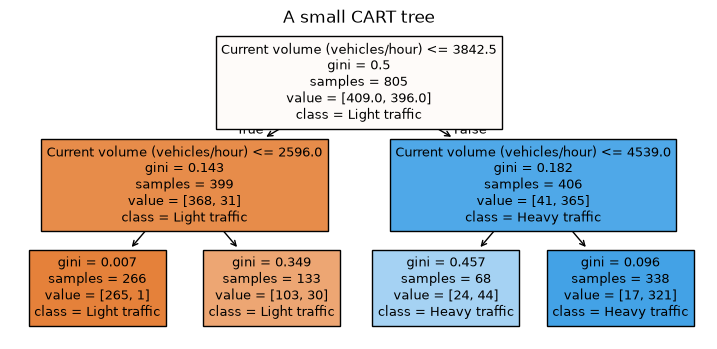

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)
tree_prediction = tree.predict(X_test)
print('CART accuracy:', round(accuracy_score(y_test, tree_prediction), 3))

plt.figure(figsize=(9, 4))
plot_tree(tree, feature_names=['Current volume (vehicles/hour)'], class_names=['Light traffic', 'Heavy traffic'], filled=True, fontsize=9)
plt.title('A small CART tree')
plt.show()

## Experiment 2 · Two ensemble models
Random forest combines many trees. AdaBoost combines small models while paying more attention to earlier mistakes. Both use the same training and testing rows as CART.

,Model,Accuracy
0,CART,0.901
1,Random forest,0.916
2,AdaBoost,0.901


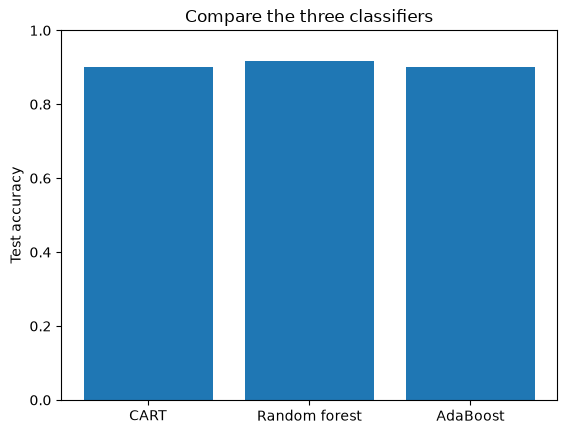

In [5]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier

forest = RandomForestClassifier(n_estimators=20, max_depth=3, random_state=42)
forest.fit(X_train, y_train)
forest_prediction = forest.predict(X_test)

boost = AdaBoostClassifier(n_estimators=20, random_state=42)
boost.fit(X_train, y_train)
boost_prediction = boost.predict(X_test)

results = pd.DataFrame({
    'Model': ['CART', 'Random forest', 'AdaBoost'],
    'Accuracy': [accuracy_score(y_test, tree_prediction),
                 accuracy_score(y_test, forest_prediction),
                 accuracy_score(y_test, boost_prediction)]
})
display(results.round(3))
plt.bar(results['Model'], results['Accuracy'])
plt.ylim(0, 1)
plt.ylabel('Test accuracy')
plt.title('Compare the three classifiers')
plt.show()

## What to explain
A tree is one model; an ensemble combines several models. Compare the measured test accuracies instead of assuming more trees always win. Two ensemble methods cover the assignment without a long list of models.

**Try:** Change `n_estimators=20` to `10`.

**Viva:** What does tree depth mean? How are random forest and boosting different?